# 04 — Auto Min/Max Reorder Point Logic

The last link in the chain: turn the inventory simulation output (notebook 03) into a concrete, per-SKU reorder recommendation — reorder point (min), max level, and suggested order quantity (via EOQ). See `src/reorder_logic.py`.

The "auto" part: this whole table is designed to be **recalculated on every forecast refresh** (e.g. nightly, once new sales data lands and Prophet reforecasts) rather than being a one-time manually-set min/max — that's the actual operational upgrade over a static min/max policy.

**Caveat, stated plainly:** the public dataset has no real inventory ledger, so on-hand inventory here is synthetic (`simulate_synthetic_on_hand`, clearly labeled). Every other piece — reorder point, EOQ, min/max, the trigger logic — is real and would plug into an actual inventory feed unchanged.

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import matplotlib.pyplot as plt
import pandas as pd

from src.reorder_logic import build_reorder_table, simulate_synthetic_on_hand

sim_results = pd.read_parquet(Path.cwd().parent / "data" / "processed" / "inventory_simulation.parquet")
sim_results.head()

,store,item,lead_time_days,target_service_level,expected_lead_time_demand,safety_stock,p95_lead_time_demand
0,1,1,7,0.95,121.850633,19.490245,141.340879
1,1,2,7,0.95,333.729857,33.440824,367.170681
2,1,3,7,0.95,201.203891,25.446069,226.649960
3,1,4,7,0.95,122.523523,19.851110,142.374633
4,1,5,7,0.95,103.668643,17.240942,120.909584


In [2]:
series_keys = list(sim_results[["store", "item"]].itertuples(index=False, name=None))
expected_demand_lookup = {
    (row.store, row.item): row.expected_lead_time_demand / row.lead_time_days
    for row in sim_results.itertuples()
}

on_hand = simulate_synthetic_on_hand(series_keys, expected_demand_lookup)
on_hand.head()

,store,item,on_hand
0,1,1,139.257866
1,1,2,1668.649285
2,1,3,891.045802
3,1,4,385.073929
4,1,5,325.815734


## Build the reorder table

`order_cost` and `holding_cost_per_unit` are placeholder procurement assumptions (documented, swappable) used only for the EOQ order-quantity calculation.

In [3]:
reorder_table = build_reorder_table(
    sim_results, on_hand, order_cost=50.0, holding_cost_per_unit=2.0
)
print(reorder_table.shape)
print(f"{reorder_table['needs_reorder'].sum()} of {len(reorder_table)} SKUs currently need reordering")
reorder_table.sort_values("needs_reorder", ascending=False).head(15)

(500, 14)
31 of 500 SKUs currently need reordering


,store,item,lead_time_days,target_service_level,expected_lead_time_demand,safety_stock,p95_lead_time_demand,on_hand,reorder_point,eoq,min_level,max_level,needs_reorder,suggested_order_qty
0,1,1,7,0.95,121.850633,19.490245,141.340879,139.257866,141.340879,563.632866,141.340879,704.973745,True,565.715878
169,4,20,7,0.95,311.385472,31.584856,342.970328,222.418194,342.970328,901.014101,342.970328,1243.984428,True,1021.566234
216,5,17,7,0.95,153.558388,22.833733,176.392122,175.495301,176.392122,632.731109,176.392122,809.123230,True,633.627929
44,1,45,7,0.95,440.960738,38.779887,479.740626,440.960738,479.740626,1072.216228,479.740626,1551.956853,True,1110.996115
453,10,4,7,0.95,148.687539,22.413864,171.101403,106.205385,171.101403,622.615175,171.101403,793.716578,True,687.511193
299,6,50,7,0.95,301.863017,32.172668,334.035685,215.616441,334.035685,887.130209,334.035685,1221.165894,True,1005.549454
302,7,3,7,0.95,151.569217,22.846725,174.415942,108.263726,174.415942,628.619600,174.415942,803.035542,True,694.771815
55,2,6,7,0.95,445.316646,39.628282,484.944928,381.699983,484.944928,1077.499009,484.944928,1562.443937,True,1180.743954
428,9,29,7,0.95,459.809739,40.203229,500.012968,394.122633,500.012968,1094.892541,500.012968,1594.905509,True,1200.782876
327,7,28,7,0.95,372.083199,36.615653,408.698852,318.928456,408.698852,984.923375,408.698852,1393.622227,True,1074.693771


## Visualize on-hand vs. min/max for a sample of SKUs

The chart that makes the policy legible at a glance: on-hand bar against its min (reorder point) and max markers. This is the visual for the Power BI "Reorder Queue" page.

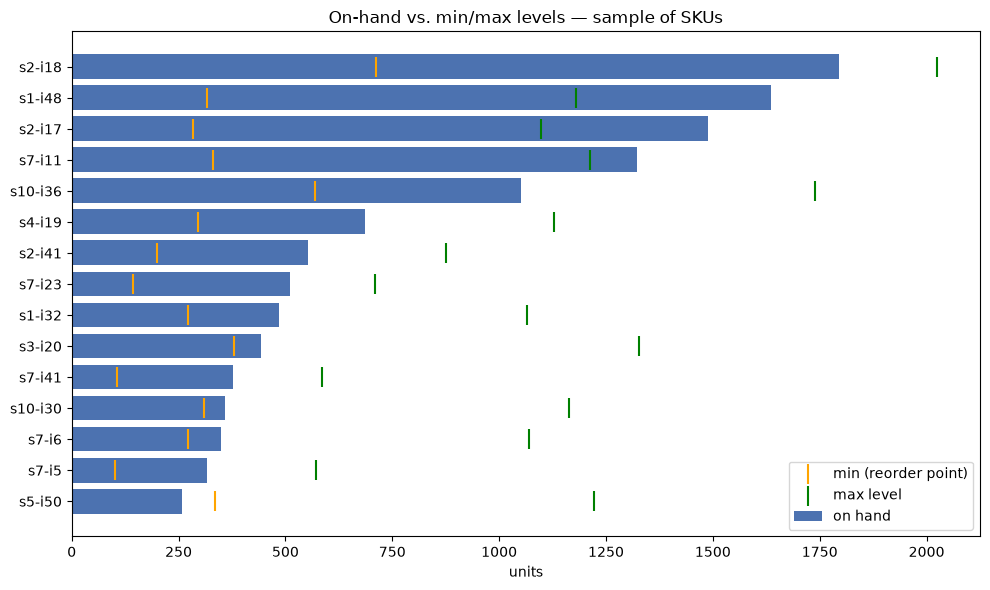

In [4]:
sample = reorder_table.sample(15, random_state=1).sort_values("on_hand")
labels = [f"s{s}-i{i}" for s, i in zip(sample["store"], sample["item"])]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(labels, sample["on_hand"], color="#4C72B0", label="on hand")
ax.scatter(sample["min_level"], labels, color="orange", marker="|", s=200, label="min (reorder point)")
ax.scatter(sample["max_level"], labels, color="green", marker="|", s=200, label="max level")
ax.legend(); ax.set_xlabel("units")
ax.set_title("On-hand vs. min/max levels — sample of SKUs")
plt.tight_layout()

## Export final tables for Power BI

This is the table the "Reorder Queue" dashboard page filters/sorts directly. See `powerbi/README.md` for the full data model this joins into.

In [5]:
reorder_table.to_csv(Path.cwd().parent / "outputs" / "reorder_recommendations.csv", index=False)